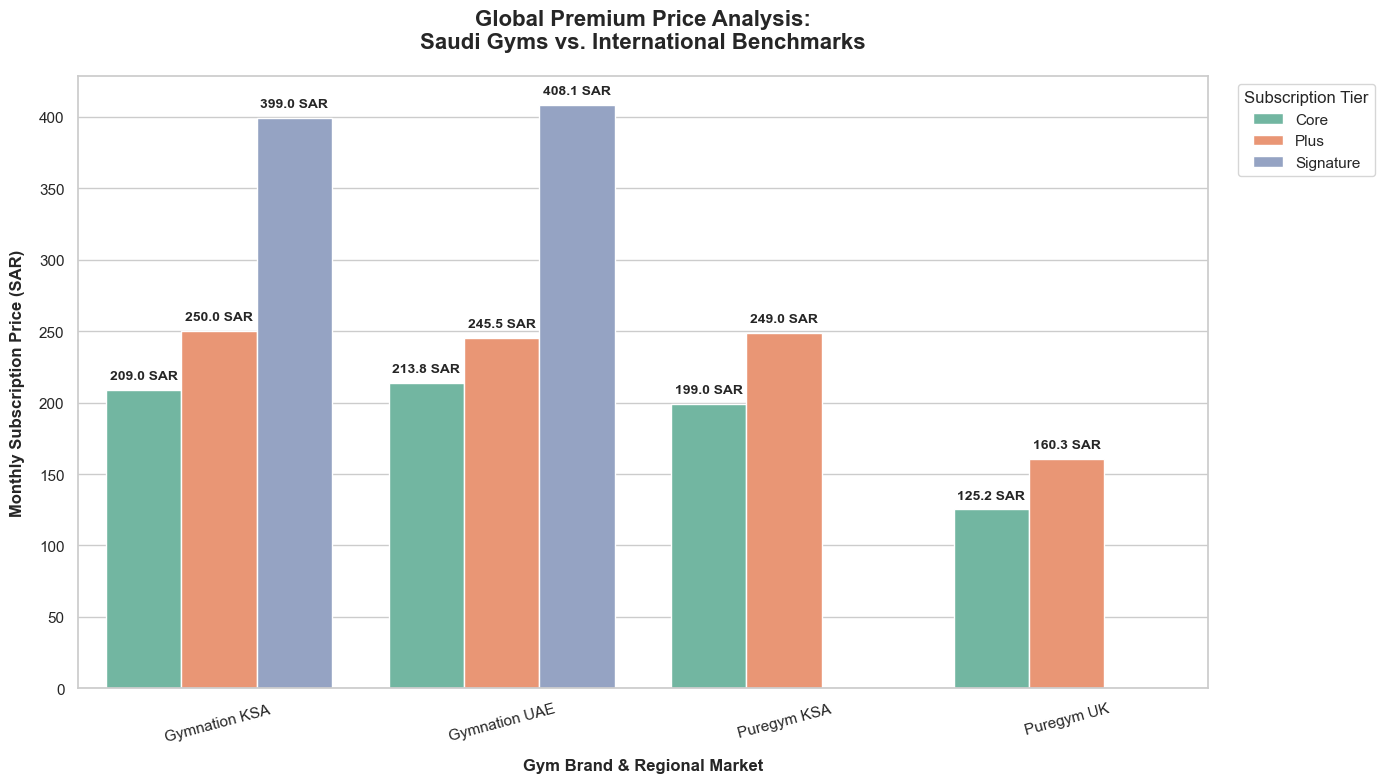

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv('Gyms_data.csv')
df.columns = df.columns.str.strip()

# 2. Set style and figure size
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

# 3. Plot the data
ax = sns.barplot(
    data=df, 
    x='Brand', 
    y='Price_SAR', 
    hue='Tier', 
    palette='Set2', 
    errorbar=None
)

# 4. Add typography and labels
plt.title("Global Premium Price Analysis:\nSaudi Gyms vs. International Benchmarks", fontsize=16, fontweight='bold', pad=20)
plt.xlabel("Gym Brand & Regional Market", fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel("Monthly Subscription Price (SAR)", fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=15, fontsize=11)
plt.legend(title="Subscription Tier", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=11, title_fontsize=12)

# 5. Add data labels on top of the bars
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f'{p.get_height():.1f} SAR', 
            (p.get_x() + p.get_width() / 2., p.get_height()), 
            ha='center', va='center', 
            xytext=(0, 10), 
            textcoords='offset points', 
            fontsize=10, fontweight='bold'
        )

# 6. Adjust layout and save
plt.tight_layout()
plt.savefig('Global_Gym_Price_Analysis.png', dpi=300)
plt.show()

In [21]:
# Create an advanced bulletproof function to handle case sensitivity and hidden spaces
def analyze_price_gap_fixed(brand_ksa, brand_intl, tier_name, market_name):
    # Standardize and filter data dynamically by making columns lowercase and stripping spaces
    filtered_ksa = df[(df['Brand'].str.lower().str.strip() == brand_ksa.lower().strip()) & 
                      (df['Tier'].str.lower().str.strip() == tier_name.lower().strip())]
    
    filtered_intl = df[(df['Brand'].str.lower().str.strip() == brand_intl.lower().strip()) & 
                        (df['Tier'].str.lower().str.strip() == tier_name.lower().strip())]
    
    # Calculate the mean prices safely
    price_ksa = filtered_ksa['Price_SAR'].mean()
    price_intl = filtered_intl['Price_SAR'].mean()
    
    # Calculate percentages and catch potential mathematical errors
    pct_diff = ((price_ksa - price_intl) / price_intl) * 100
    abs_diff = abs(price_ksa - price_intl)
    
    # Dynamically determine the relationship status
    if pct_diff > 0:
        status = "MORE EXPENSIVE than"
        sign = "+"
    elif pct_diff < 0:
        status = "CHEAPER than"
        sign = "-"
    else:
        status = "EQUIVALENT to"
        sign = ""
        
    # Print the conclusion dynamically
    print(f"• {tier_name} Tier: KSA is {abs(pct_diff):.1f}% {status} {market_name} ({sign}{abs_diff:.1f} SAR/mo)")

# Run the dynamic analysis with safety filters enabled
print("---  AUTOMATED GLOBAL PRICE GAP ANALYTICS --- \n")

print("======= PUREGYM BENCHMARKS =======")
analyze_price_gap_fixed('Puregym KSA', 'Puregym UK', 'Core', 'the UK')
analyze_price_gap_fixed('Puregym KSA', 'Puregym UK', 'Plus', 'the UK')

print("\n======= GYMNATION BENCHMARKS =======")
analyze_price_gap_fixed('Gymnation KSA', 'Gymnation UAE', 'Core', 'UAE (Dubai)')
analyze_price_gap_fixed('Gymnation KSA', 'Gymnation UAE', 'Plus', 'UAE (Dubai)')
analyze_price_gap_fixed('Gymnation KSA', 'Gymnation UAE', 'Signature', 'UAE (Dubai)')

---  AUTOMATED GLOBAL PRICE GAP ANALYTICS --- 

======= PUREGYM BENCHMARKS =======
• Core Tier: KSA is 58.9% MORE EXPENSIVE than the UK (+73.8 SAR/mo)
• Plus Tier: KSA is 55.3% MORE EXPENSIVE than the UK (+88.7 SAR/mo)

======= GYMNATION BENCHMARKS =======
• Core Tier: KSA is 2.2% CHEAPER than UAE (Dubai) (-4.8 SAR/mo)
• Plus Tier: KSA is 1.8% MORE EXPENSIVE than UAE (Dubai) (+4.5 SAR/mo)
• Signature Tier: KSA is 2.2% CHEAPER than UAE (Dubai) (-9.1 SAR/mo)
